In [1]:
# ==============================================================================
# A.1. Импорт библиотек и загрузка обработанного датасета
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем стиль для графиков
sns.set_style("whitegrid")
print("Библиотеки успешно импортированы.")

# --- Загрузка данных ---
# [Важно!] Убедитесь, что путь к файлу указан верно.
# Скрипт сохранял его в 'data/processed/'. Ноутбук находится в 'notebooks/'.
# Значит, относительный путь будет '../data/processed/featured_dataset.csv'
featured_data_path = '../data/processed/featured_dataset.csv'

try:
    df_featured = pd.read_csv(featured_data_path)
    print(f"Обработанный датасет успешно загружен. Путь: '{featured_data_path}'")

except FileNotFoundError:
    print(f"Ошибка: Файл не найден по пути '{featured_data_path}'.")
    print("Пожалуйста, убедитесь, что вы запустили скрипт предобработки, и проверьте путь.")
    df_featured = None

Библиотеки успешно импортированы.
Обработанный датасет успешно загружен. Путь: '../data/processed/featured_dataset.csv'


In [2]:
# ==============================================================================
# A.2. Общая информация и проверка структуры
# ==============================================================================
if df_featured is not None:
    print("\n--- Общая информация об обработанном датасете ---")
    print(f"Новый размер датасета (строки, колонки): {df_featured.shape}")
    
    print("\n--- Первые 5 строк данных (прокрутите вправо, чтобы увидеть новые колонки) ---")
    # Увеличим количество отображаемых колонок для наглядности
    pd.set_option('display.max_columns', 200)
    display(df_featured.head())
    
    # --- Проверка наличия новых и отсутствия старых колонок ---
    print("\n--- Верификация изменений в структуре ---")
    
    original_cols_to_drop = ['p', 'nTot', 'maintenance_flag']
    cols_dropped = all(col not in df_featured.columns for col in original_cols_to_drop)
    if cols_dropped:
        print(f"  [OK] Колонки {original_cols_to_drop} успешно удалены.")
    else:
        print(f"  [Внимание] Не все ожидаемые колонки были удалены.")
        
    new_feature_example = 'E_mu_Z_lag_1'
    if new_feature_example in df_featured.columns:
        print(f"  [OK] Новые признаки, например '{new_feature_example}', успешно добавлены.")
    else:
        print(f"  [Внимание] Новые признаки не найдены в датасете.")
        
    # --- Проверка типов данных ---
    print("\n--- Проверка типов данных новых колонок ---")
    # Выведем типы данных для последних 10 колонок (это должны быть наши новые признаки)
    display(df_featured.iloc[:, -10:].dtypes)

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Общая информация об обработанном датасете ---
Новый размер датасета (строки, колонки): (328617, 151)

--- Первые 5 строк данных (прокрутите вправо, чтобы увидеть новые колонки) ---


,block_id,frame_idx,E_mu_Z,E_mu_phys_est,E_mu_X,E_nu1_X,E_nu2_X,E_nu1_Z,E_nu2_Z,N_mu_X,M_mu_XX,M_mu_XZ,M_mu_X,N_mu_Z,M_mu_ZZ,M_mu_Z,N_nu1_X,M_nu1_XX,M_nu1_XZ,M_nu1_X,N_nu1_Z,M_nu1_ZZ,M_nu1_Z,N_nu2_X,M_nu2_XX,M_nu2_XZ,M_nu2_X,N_nu2_Z,M_nu2_ZZ,M_nu2_Z,unitsRatio,bayesImVoltage,opticalPower,polarizerVoltages[0],polarizerVoltages[1],polarizerVoltages[2],polarizerVoltages[3],temp_1,biasVoltage_1,temp_2,biasVoltage_2,synErr,N_EC_rounds,estimator_name,f_EC,E_mu_Z_est,R,s,E_mu_Z_lag_1,E_mu_Z_lag_2,E_mu_Z_lag_3,E_mu_Z_lag_5,E_mu_Z_est_lag_1,E_mu_Z_est_lag_2,E_mu_Z_est_lag_3,E_mu_Z_est_lag_5,f_EC_lag_1,f_EC_lag_2,f_EC_lag_3,f_EC_lag_5,M_nu1_XX_lag_1,M_nu1_XX_lag_2,M_nu1_XX_lag_3,M_nu1_XX_lag_5,M_nu2_XX_lag_1,M_nu2_XX_lag_2,M_nu2_XX_lag_3,M_nu2_XX_lag_5,M_mu_XX_lag_1,M_mu_XX_lag_2,M_mu_XX_lag_3,M_mu_XX_lag_5,polarizerVoltages[1]_lag_1,polarizerVoltages[1]_lag_2,polarizerVoltages[1]_lag_3,polarizerVoltages[1]_lag_5,temp_1_lag_1,temp_1_lag_2,temp_1_lag_3,temp_1_lag_5,biasVoltage_1_lag_1,biasVoltage_1_lag_2,biasVoltage_1_lag_3,biasVoltage_1_lag_5,estimator_name_lag_1,estimator_name_lag_2,estimator_name_lag_3,estimator_name_lag_5,E_mu_Z_roll_mean_5,E_mu_Z_roll_std_5,E_mu_Z_roll_max_5,E_mu_Z_roll_mean_10,E_mu_Z_roll_std_10,E_mu_Z_roll_max_10,E_mu_Z_est_roll_mean_5,E_mu_Z_est_roll_std_5,E_mu_Z_est_roll_max_5,E_mu_Z_est_roll_mean_10,E_mu_Z_est_roll_std_10,E_mu_Z_est_roll_max_10,f_EC_roll_mean_5,f_EC_roll_std_5,f_EC_roll_max_5,f_EC_roll_mean_10,f_EC_roll_std_10,f_EC_roll_max_10,M_nu1_XX_roll_mean_5,M_nu1_XX_roll_std_5,M_nu1_XX_roll_max_5,M_nu1_XX_roll_mean_10,M_nu1_XX_roll_std_10,M_nu1_XX_roll_max_10,M_nu2_XX_roll_mean_5,M_nu2_XX_roll_std_5,M_nu2_XX_roll_max_5,M_nu2_XX_roll_mean_10,M_nu2_XX_roll_std_10,M_nu2_XX_roll_max_10,M_mu_XX_roll_mean_5,M_mu_XX_roll_std_5,M_mu_XX_roll_max_5,M_mu_XX_roll_mean_10,M_mu_XX_roll_std_10,M_mu_XX_roll_max_10,polarizerVoltages[1]_roll_mean_5,polarizerVoltages[1]_roll_std_5,polarizerVoltages[1]_roll_max_5,polarizerVoltages[1]_roll_mean_10,polarizerVoltages[1]_roll_std_10,polarizerVoltages[1]_roll_max_10,temp_1_roll_mean_5,temp_1_roll_std_5,temp_1_roll_max_5,temp_1_roll_mean_10,temp_1_roll_std_10,temp_1_roll_max_10,biasVoltage_1_roll_mean_5,biasVoltage_1_roll_std_5,biasVoltage_1_roll_max_5,biasVoltage_1_roll_mean_10,biasVoltage_1_roll_std_10,biasVoltage_1_roll_max_10,estimator_name_roll_mean_5,estimator_name_roll_std_5,estimator_name_roll_max_5,estimator_name_roll_mean_10,estimator_name_roll_std_10,estimator_name_roll_max_10,delta_err_est,ratio_M_mu_nu1,ratio_M_mu_nu2
0,989611274,0,0.10787,0.02315,0.00000,0.00000,0.00000,0.00000,0.00000,5540263.0,442.0,3266.0,3708.0,38787968.0,27200.0,31065.0,705182.0,442.0,138.0,156.0,4945814.0,847.0,963.0,707571.0,442.0,6.0,8.0,4945202.0,77.0,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,2.508240,0.03297,0.75,3339,1461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.107870,NaN,0.10787,0.107870,NaN,0.10787,0.750000,NaN,0.75,0.750000,NaN,0.75,0.032970,NaN,0.03297,0.032970,NaN,0.03297,442.000000,NaN,442.0,442.000000,NaN,442.0,442.000000,NaN,442.0,442.000000,NaN,442.0,442.000000,NaN,442.0,442.000000,NaN,442.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,2.508240,NaN,2.50824,2.508240,NaN,2.50824,-0.64213,1.0,1.0
1,989611274,1,0.10713,0.02427,0.04072,0.11111,0.50000,0.04723,0.40260,5539181.0,481.0,3370.0,3851.0,38789605.0,27469.0,31413.0,706546.0,481.0,126.0,138.0,4947599.0,853.0,963.0,705938.0,481.0,14.0,17.0,4943131.0,76.0,91.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44,1,2.508240,0.05794,0.65,3584,1216,0.10787,NaN,NaN,NaN,0.75,NaN,NaN,NaN,0.03297,NaN,NaN,NaN,442.0,NaN,NaN,NaN,442.0,NaN,NaN,NaN,442.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,2.508240,NaN,NaN,NaN,0.107500,0.000523,0.10787,0.107500,0.000523,0.10787,0.700000,0.070711,0.75,0.700000,0.070711,0.75,0.045455,0.017656,0.05794,0.045455,0.017656,0.05794,461.50000


--- Верификация изменений в структуре ---
  [OK] Колонки ['p', 'nTot', 'maintenance_flag'] успешно удалены.
  [OK] Новые признаки, например 'E_mu_Z_lag_1', успешно добавлены.

--- Проверка типов данных новых колонок ---


biasVoltage_1_roll_max_10      float64
estimator_name_roll_mean_5     float64
estimator_name_roll_std_5      float64
estimator_name_roll_max_5      float64
estimator_name_roll_mean_10    float64
estimator_name_roll_std_10     float64
estimator_name_roll_max_10     float64
delta_err_est                  float64
ratio_M_mu_nu1                 float64
ratio_M_mu_nu2                 float64
dtype: object

In [3]:
# ==============================================================================
# A.3. Краткая сводка по пропускам
# ==============================================================================
if df_featured is not None:
    total_missing = df_featured.isnull().sum().sum()
    print(f"\n--- Общее количество пропусков в датасете ---")
    print(f"В итоговом датасете {total_missing} пропущенных значений.")
    print("Это ожидаемое поведение после генерации временных признаков.")
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Общее количество пропусков в датасете ---
В итоговом датасете 106990 пропущенных значений.
Это ожидаемое поведение после генерации временных признаков.


In [4]:
# ==============================================================================
# B.1. Расчет корреляции всех признаков с целевой переменной R
# ==============================================================================
if df_featured is not None:
    print("--- Расчет корреляции всех числовых признаков с целевой переменной R ---")
    
    # Рассчитываем корреляцию всех признаков с нашей целью 'R'
    correlations_with_target_R = df_featured.corr(numeric_only=True)['R'].dropna()
    
    # Для определения важности нам нужен модуль корреляции
    correlations_with_target_R_abs = abs(correlations_with_target_R)
    
    # Сортируем по убыванию модуля, чтобы видеть самые сильные связи
    sorted_correlations = correlations_with_target_R.loc[correlations_with_target_R_abs.sort_values(ascending=False).index]
    
    # Исключаем корреляцию 'R' с самой собой (она всегда равна 1)
    sorted_correlations = sorted_correlations.drop('R')
    
    print("\nТоп-15 самых важных признаков (по модулю корреляции с R):")
    display(sorted_correlations.head(15).to_frame())

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

--- Расчет корреляции всех числовых признаков с целевой переменной R ---

Топ-15 самых важных признаков (по модулю корреляции с R):


,R
s,-1.000000
E_mu_Z_est,0.380809
delta_err_est,-0.300907
estimator_name_roll_mean_10,-0.294359
estimator_name_roll_mean_5,-0.290270
estimator_name_roll_max_5,-0.241136
estimator_name_lag_3,-0.232756
estimator_name_lag_2,-0.220843
E_mu_Z_est_lag_1,0.219127
estimator_name_roll_std_5,-0.203914


C:\Users\iboro\AppData\Local\Temp\ipykernel_20056\2603824604.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='vlag')


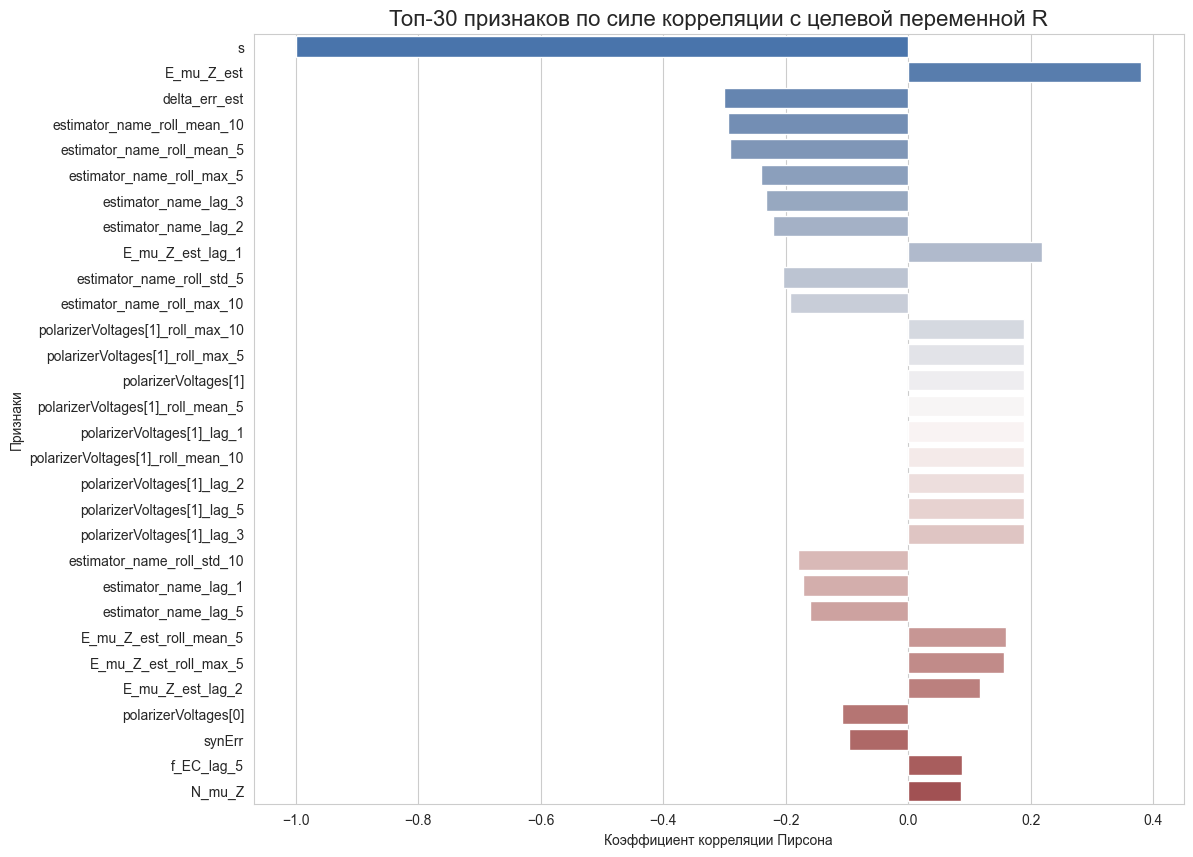

In [5]:
# ==============================================================================
# B.2. Визуализация важности признаков
# ==============================================================================
if df_featured is not None and 'sorted_correlations' in locals():
    # Выбираем топ-30 признаков для визуализации
    top_n = 30
    top_features = sorted_correlations.head(top_n)
    
    plt.figure(figsize=(12, 10))
    sns.barplot(x=top_features.values, y=top_features.index, palette='vlag')
    
    plt.title(f'Топ-{top_n} признаков по силе корреляции с целевой переменной R', fontsize=16)
    plt.xlabel('Коэффициент корреляции Пирсона')
    plt.ylabel('Признаки')
    plt.show()

else:
    print("Датафрейм не загружен или переменная sorted_correlations не создана.")

--- Анализ распределения ключевых сгенерированных признаков ---


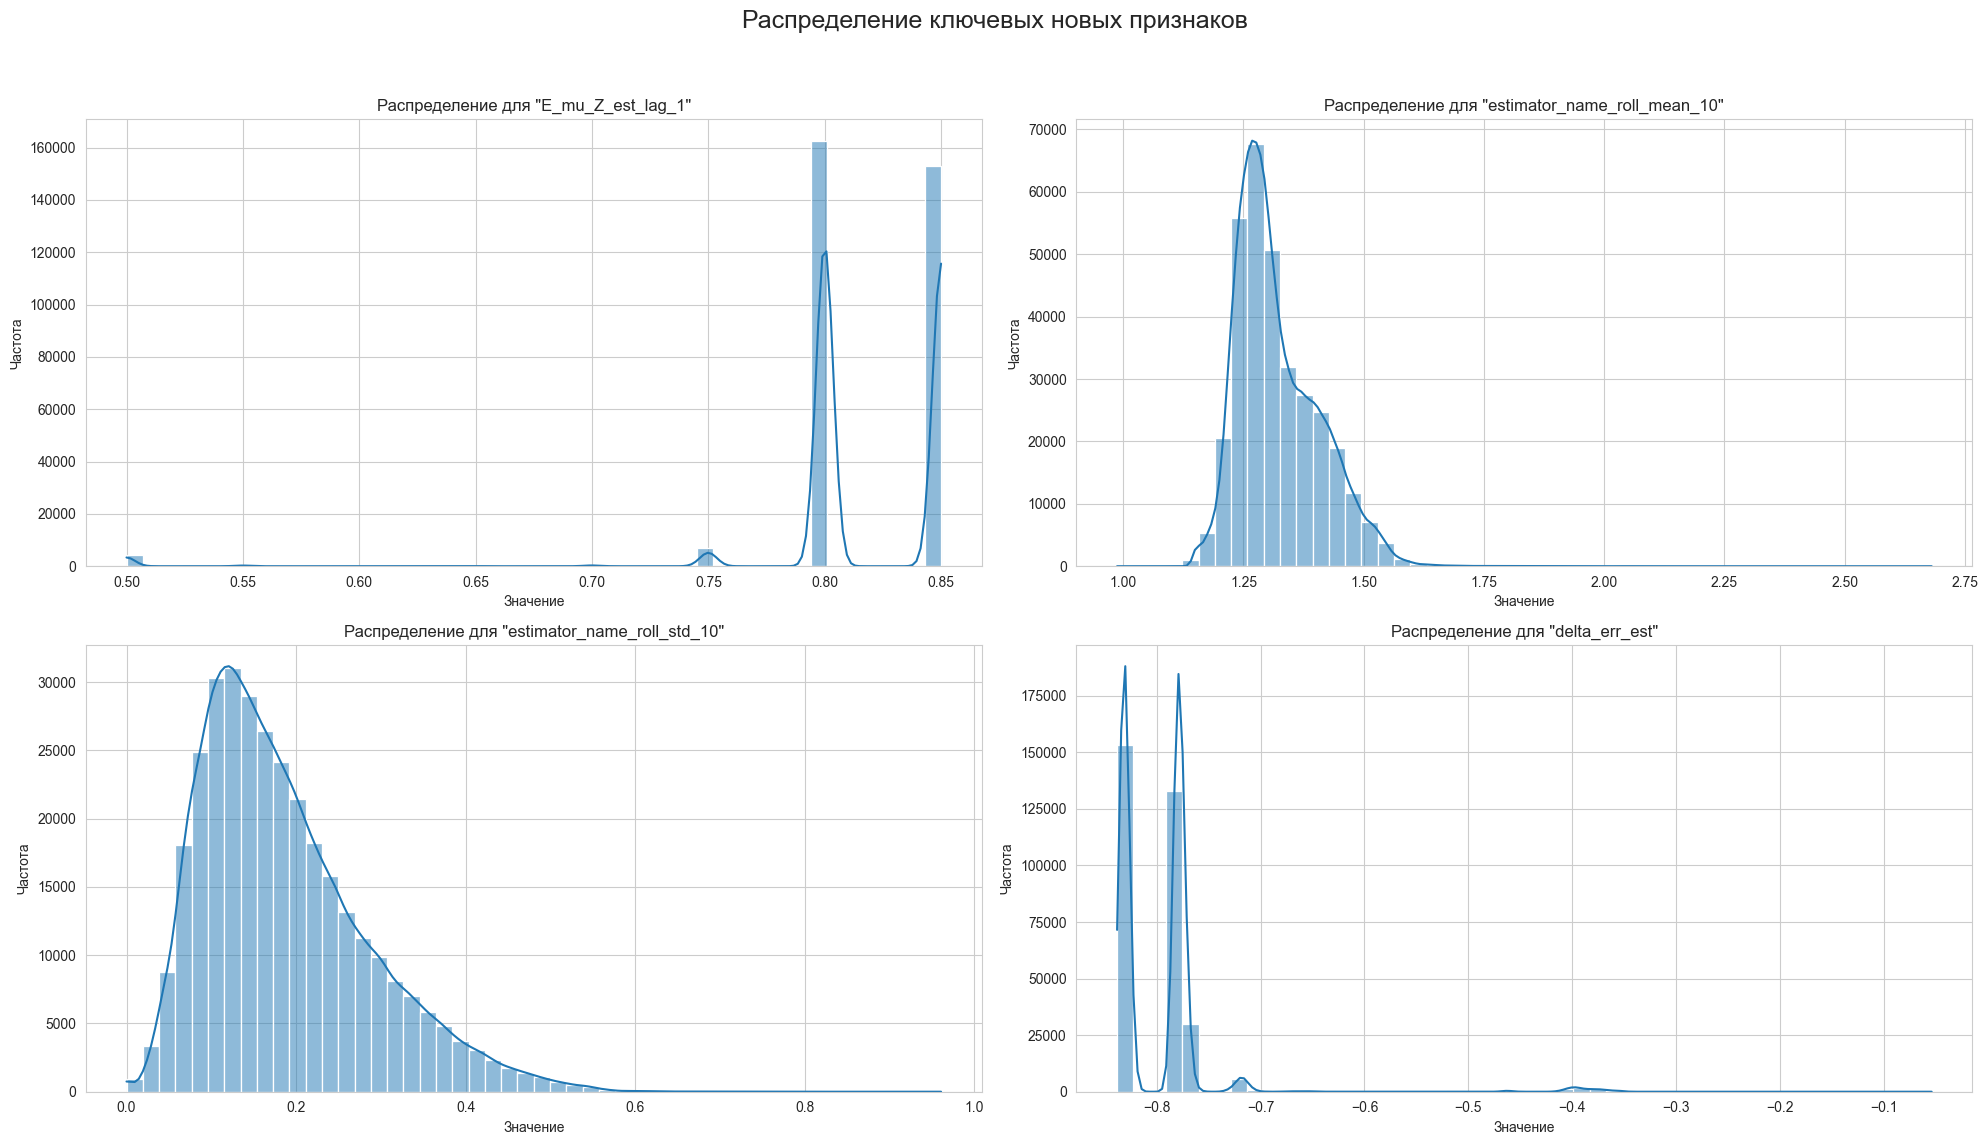

In [6]:
# ==============================================================================
# C.1. Изучение распределений
# ==============================================================================
if df_featured is not None:
    print("--- Анализ распределения ключевых сгенерированных признаков ---")
    
    # Выбираем признаки для анализа, как и планировали
    # Добавим также один из "неожиданных героев" - estimator_name_roll_mean_10
    features_to_analyze = [
        'E_mu_Z_est_lag_1',              # Пример лага
        'estimator_name_roll_mean_10',   # Пример скользящего среднего
        'estimator_name_roll_std_10',    # Пример скользящего ст. отклонения
        'delta_err_est'                  # Пример признака-взаимодействия
    ]
    
    # Создаем сетку графиков
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle('Распределение ключевых новых признаков', fontsize=18)
    
    # `axes.flatten()` позволяет удобно итерироваться по сетке 2x2
    axes_flat = axes.flatten()
    
    for i, col in enumerate(features_to_analyze):
        # Работаем с данными без пропусков для корректного построения
        series_to_plot = df_featured[col].dropna()
        
        sns.histplot(series_to_plot, kde=True, ax=axes_flat[i], bins=50)
        axes_flat[i].set_title(f'Распределение для "{col}"')
        axes_flat[i].set_xlabel('Значение')
        axes_flat[i].set_ylabel('Частота')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

--- Анализ мультиколлинеарности для 'семейства' признаков E_mu_Z_est ---

Выбраны следующие признаки для анализа:
['E_mu_Z_est', 'E_mu_Z_est', 'E_mu_Z_est_lag_1', 'E_mu_Z_est_lag_2', 'E_mu_Z_est_lag_3', 'E_mu_Z_est_lag_5', 'E_mu_Z_est_roll_mean_5', 'E_mu_Z_est_roll_std_5', 'E_mu_Z_est_roll_max_5', 'E_mu_Z_est_roll_mean_10', 'E_mu_Z_est_roll_std_10', 'E_mu_Z_est_roll_max_10']



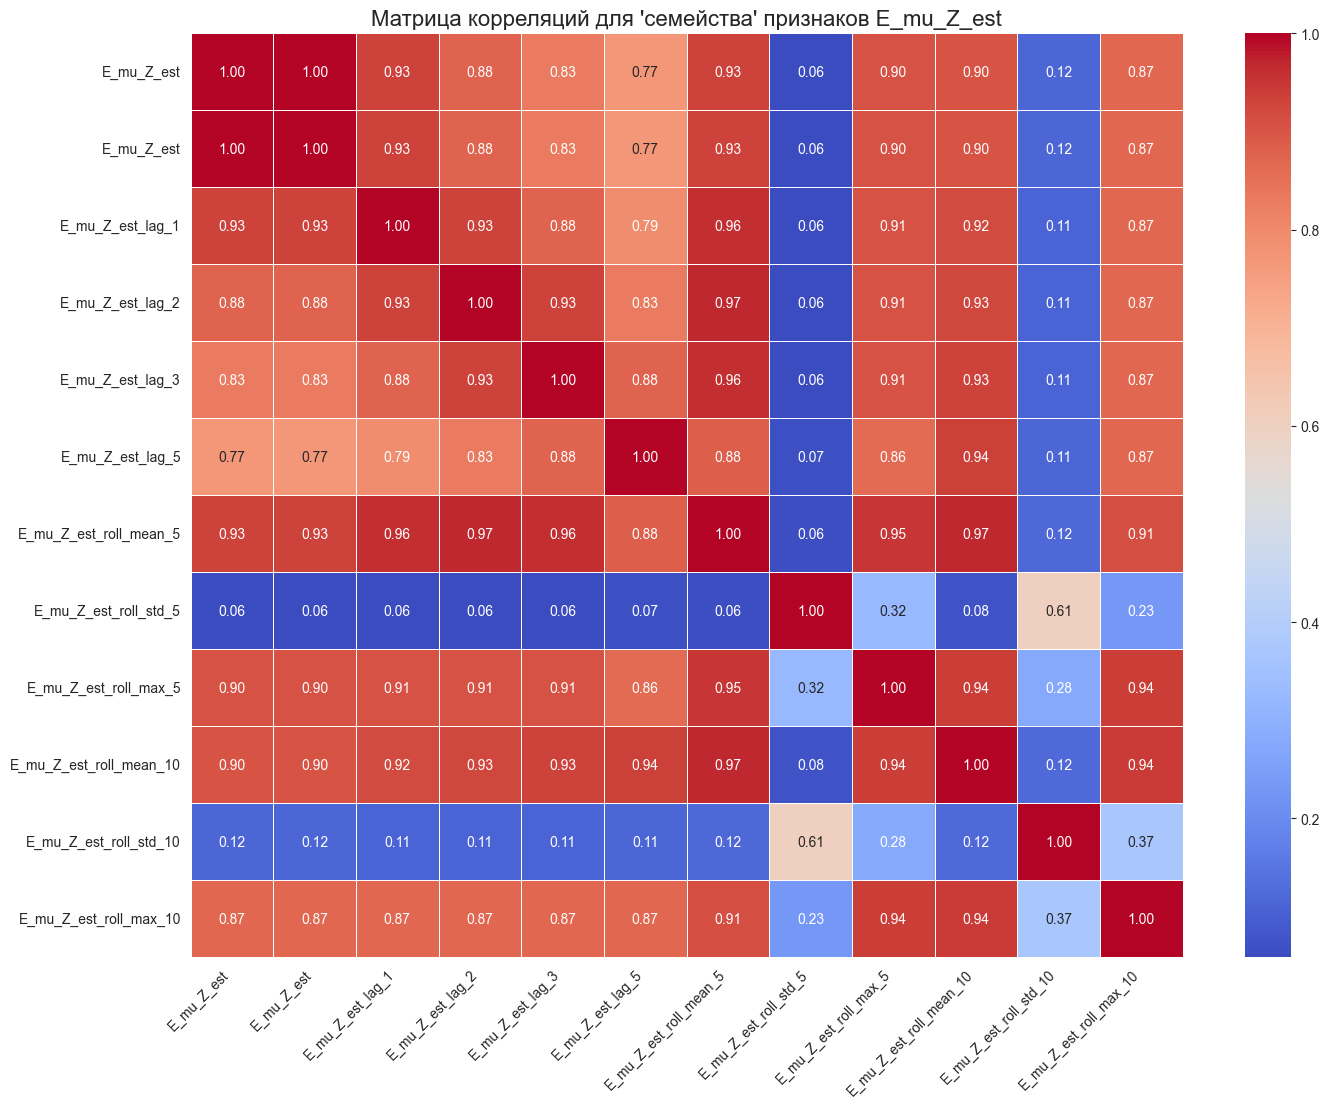

In [7]:
# ==============================================================================
# D.1. Анализ мультиколлинеарности "семейства" признаков
# ==============================================================================
if df_featured is not None:
    print("--- Анализ мультиколлинеарности для 'семейства' признаков E_mu_Z_est ---")
    
    # Собираем все новые признаки, которые были сгенерированы из 'E_mu_Z_est'
    family_cols_est = [col for col in df_featured.columns if 'E_mu_Z_est' in col]
    # Добавим для сравнения и исходный признак
    family_cols_est.insert(0, 'E_mu_Z_est')
    
    print(f"\nВыбраны следующие признаки для анализа:\n{family_cols_est}\n")
    
    # Рассчитываем матрицу корреляций для этой группы
    family_corr_matrix = df_featured[family_cols_est].corr()
    
    # Визуализируем матрицу
    plt.figure(figsize=(16, 12))
    sns.heatmap(family_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title("Матрица корреляций для 'семейства' признаков E_mu_Z_est", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Анализ мультиколлинеарности для 'семейства' признаков estimator_name ---

Выбраны следующие признаки для анализа:
['estimator_name', 'estimator_name', 'estimator_name_lag_1', 'estimator_name_lag_2', 'estimator_name_lag_3', 'estimator_name_lag_5', 'estimator_name_roll_mean_5', 'estimator_name_roll_std_5', 'estimator_name_roll_max_5', 'estimator_name_roll_mean_10', 'estimator_name_roll_std_10', 'estimator_name_roll_max_10']



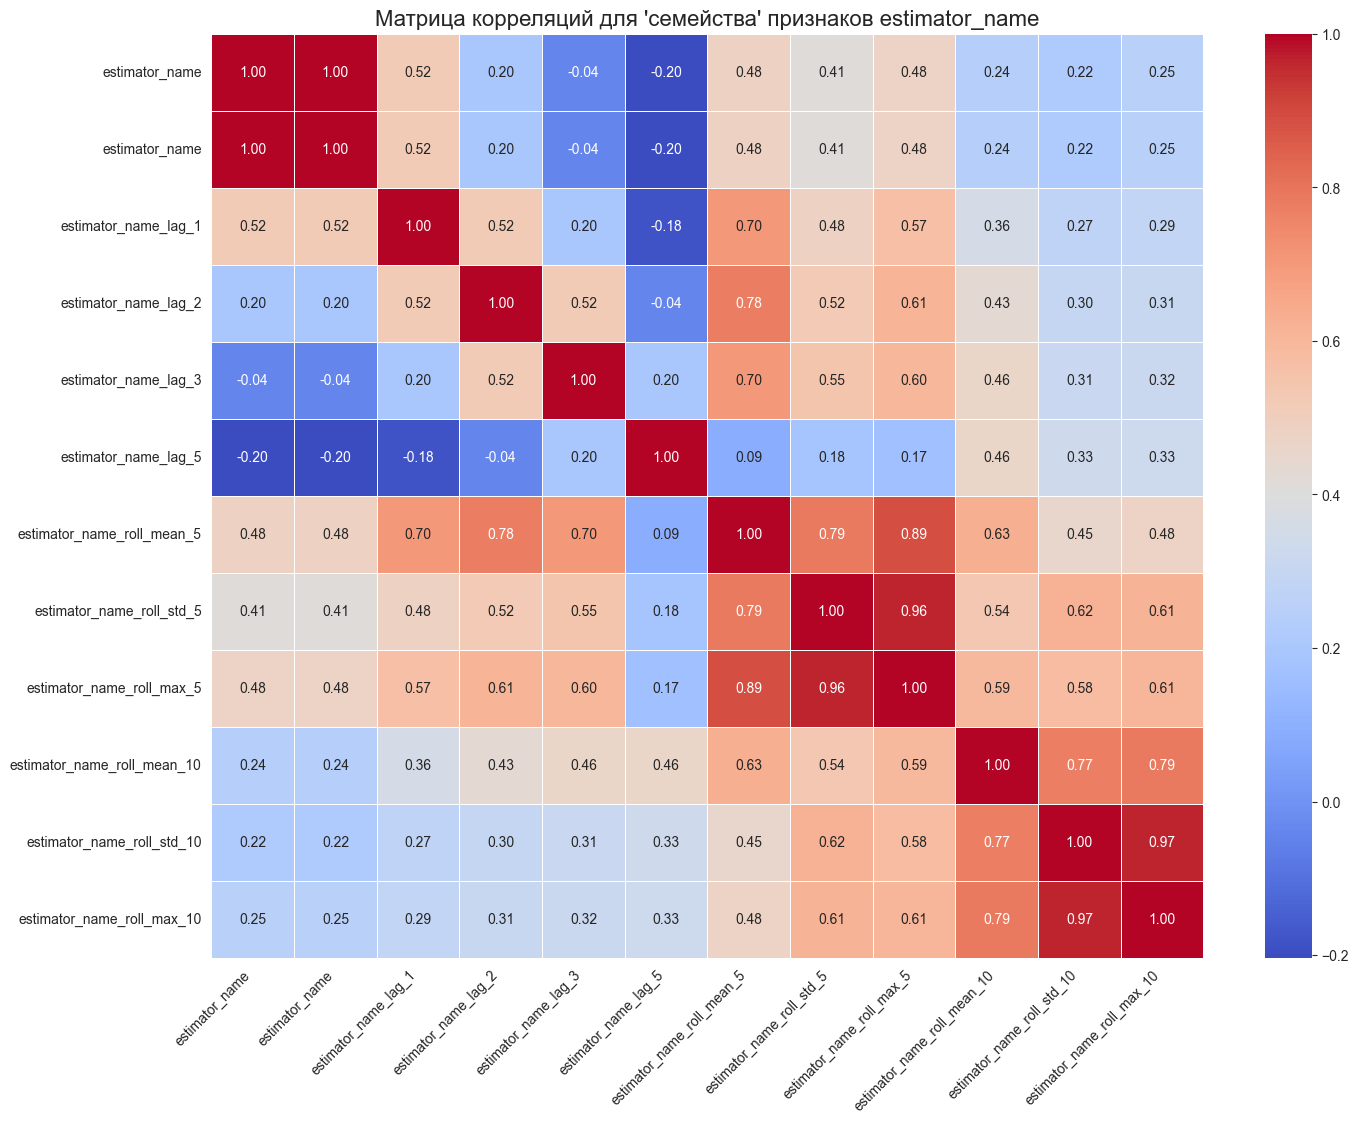

In [8]:
# ==============================================================================
# D.2. Анализ мультиколлинеарности для второго "семейства" признаков
# ==============================================================================
if df_featured is not None:
    print("\n--- Анализ мультиколлинеарности для 'семейства' признаков estimator_name ---")
    
    # Повторим то же самое для нашего "неожиданного героя" - estimator_name
    family_cols_estimator = [col for col in df_featured.columns if 'estimator_name' in col]
    family_cols_estimator.insert(0, 'estimator_name')

    print(f"\nВыбраны следующие признаки для анализа:\n{family_cols_estimator}\n")
    
    family_corr_matrix_2 = df_featured[family_cols_estimator].corr()
    
    plt.figure(figsize=(16, 12))
    sns.heatmap(family_corr_matrix_2, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title("Матрица корреляций для 'семейства' признаков estimator_name", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")